In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# COMPARANDO CATEGORIAS

Os gráficos deste capítulo visam ajudar nossos leitores a comparar valores entre categorias. Barras, linhas e pontos permitem que os leitores façam comparações tanto dentro de grupos quanto entre eles. Em alguns casos, queremos que o leitor visualize tanto os níveis quanto as variações, ou alguma outra combinação de variáveis; em outros, queremos concentrar sua atenção em uma comparação específica.

O desafio ao comparar dados categóricos é decidir o que queremos que o gráfico transmita. Existe um argumento ou uma narrativa principal? Há algum aspecto que possa ser identificado como a comparação mais importante que se deseja que o leitor faça? Como criadores de gráficos, precisamos priorizar a função que queremos que eles desempenhem. Ao incluir todas as barras ou pontos no gráfico, podemos acabar obscurecendo a mensagem que desejamos transmitir.

Este capítulo começa com o gráfico de barras. Assim como o gráfico de linhas que dará início ao próximo capítulo, o gráfico de barras é familiar à maioria dos leitores, o que o torna uma escolha conveniente para orientá-los ao comparar categorias ou observar mudanças ao longo do tempo. Ele também ocupa o topo do diagrama de hierarquia de percepção visual. Não é obrigatório fornecer sempre os valores exatos aos leitores, mas, quando o fazemos, o gráfico de barras é uma excelente escolha.



## GRÁFICO DE PONTOS

O gráfico de pontos (às vezes chamado de gráfico de halteres ou *dumbbell chart*) é uma das minhas alternativas favoritas aos gráficos de barras pareadas ou empilhadas. Desenvolvido por William Cleveland, um dos pioneiros na pesquisa de visualização de dados, o gráfico de pontos utiliza um símbolo — frequentemente, mas nem sempre, um círculo — correspondente ao valor do dado, conectado por uma linha ou seta. Os valores dos dados correspondem a um eixo e os grupos ao outro; não é necessário que estejam ordenados de uma maneira específica, embora a ordenação possa ajudar.

O gráfico de pontos é uma maneira simples de comparar categorias — especialmente quando há muitas delas —, evitando o excesso de tinta e a poluição visual que as barras poderiam causar na página. Para este exemplo, vamos analisar as pontuações em testes escolares ao redor do mundo provenientes do Programa Internacional de Avaliação de Alunos (PISA, um conjunto internacional de testes de desempenho realizados por estudantes de 15 anos nas áreas de leitura, matemática e ciências). Podemos facilmente representar as pontuações de matemática e leitura de um grupo de países usando um gráfico de barras simples, mas a presença de vinte barras torna o gráfico pesado e denso.

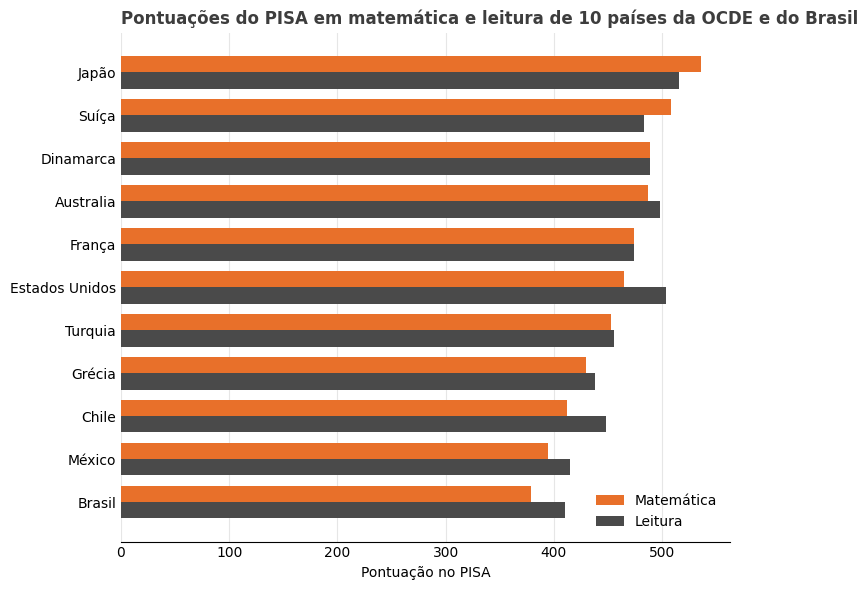

In [2]:
pisa = pd.read_csv("../Data/pisa_math_reading.csv")
pisa = pisa.sort_values("Matemática").reset_index(drop=True)

GRAFITE = "#3D3D3D"
CORES = {"Matemática": "#E8702A", "Leitura": "#4A4A4A"}

pos = np.arange(len(pisa))
altura = 0.38

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.barh(pos + altura / 2, pisa["Matemática"], height=altura,
        label="Matemática", color=CORES["Matemática"])
ax.barh(pos - altura / 2, pisa["Leitura"], height=altura,
        label="Leitura", color=CORES["Leitura"])

ax.set_yticks(pos, pisa["País"])
ax.set_xlabel("Pontuação no PISA")
ax.set_title("Pontuações do PISA em matemática e leitura de 10 países da OCDE e do Brasil",
             loc="left", fontsize=12, color=GRAFITE, weight="bold")
ax.xaxis.grid(True, color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(length=0)
ax.legend(frameon=False, loc="lower right")

fig.tight_layout()
plt.show()

Em contrapartida, o gráfico de pontos (*dot plot*) apresenta os mesmos dados com um ponto em cada valor, conectados por uma linha para indicar a amplitude ou a diferença. Os círculos consomem menos tinta do que as barras, tornando o visual mais leve graças ao maior espaço vazio. Os rótulos dos países são posicionados próximos ao ponto mais à esquerda, embora também possam ser dispostos à esquerda, ao longo do eixo vertical. Se necessário, os valores dos dados podem ser colocados ao lado, acima ou dentro de cada círculo.

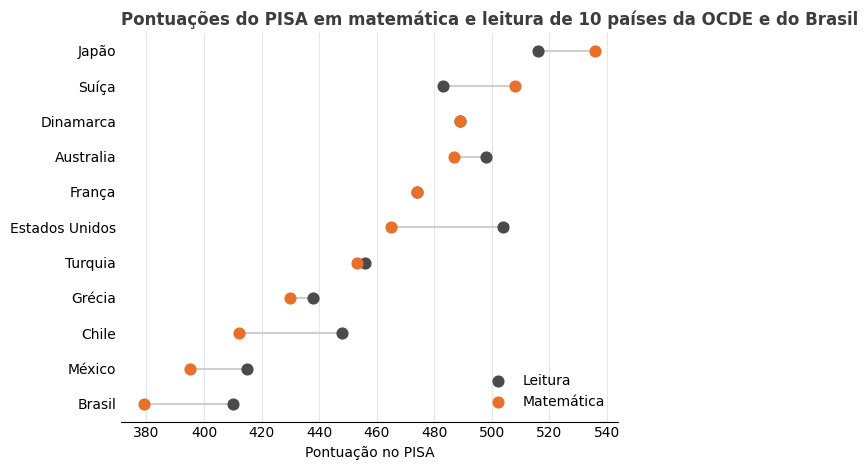

In [3]:
# Linha conectando os dois pontos de cada país (amplitude entre Leitura e Matemática)
for pais, matematica, leitura in zip(pisa["País"], pisa["Matemática"], pisa["Leitura"]):
    plt.plot([leitura, matematica], [pais, pais], color="#CFCFCF", zorder=2, linewidth=1.5)

# Pontos das duas pontuações
plt.scatter(pisa["Leitura"], pisa["País"], color=CORES["Leitura"], zorder=3, label="Leitura", s=60)
plt.scatter(pisa["Matemática"], pisa["País"], color=CORES["Matemática"], zorder=3, label="Matemática", s=60)

plt.xlabel("Pontuação no PISA")
plt.title("Pontuações do PISA em matemática e leitura de 10 países da OCDE e do Brasil",
          loc="left", fontsize=12, color=GRAFITE, weight="bold")
plt.gca().xaxis.grid(True, color="#E6E6E6", linewidth=0.8)
plt.gca().set_axisbelow(True)
for lado in ("top", "right", "left"):
    plt.gca().spines[lado].set_visible(False)
plt.gca().tick_params(length=0)
plt.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

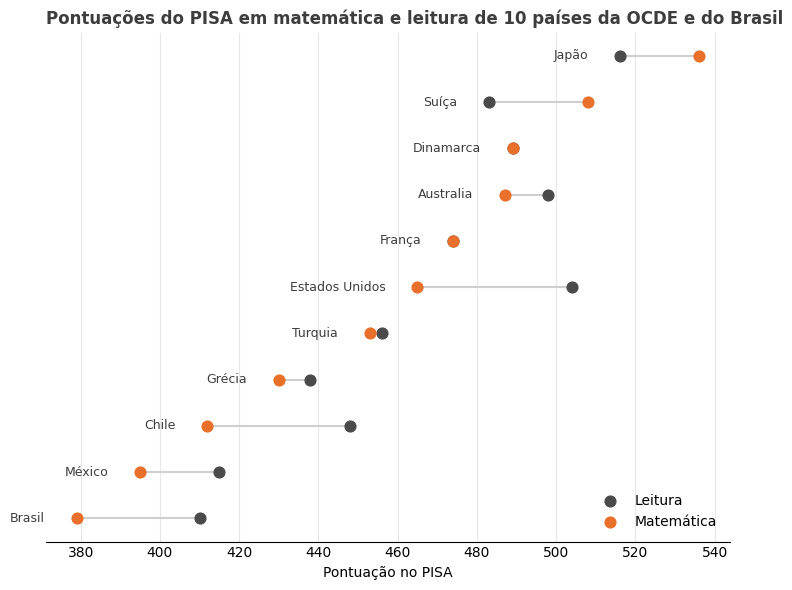

In [4]:
# Versão sem rótulos no eixo y: o nome do país é posicionado junto ao ponto mais à esquerda
fig, ax = plt.subplots(figsize=(7.5, 6))

for pais, matematica, leitura in zip(pisa["País"], pisa["Matemática"], pisa["Leitura"]):
    ax.plot([leitura, matematica], [pais, pais], color="#CFCFCF", zorder=2, linewidth=1.5)
    ponto_esquerdo = min(leitura, matematica)
    ax.text(ponto_esquerdo - 8, pais, pais, ha="right", va="center", fontsize=9, color=GRAFITE)

ax.scatter(pisa["Leitura"], pisa["País"], color=CORES["Leitura"], zorder=3, label="Leitura", s=60)
ax.scatter(pisa["Matemática"], pisa["País"], color=CORES["Matemática"], zorder=3, label="Matemática", s=60)

ax.set_xlabel("Pontuação no PISA")
ax.set_title("Pontuações do PISA em matemática e leitura de 10 países da OCDE e do Brasil",
             loc="left", fontsize=12, color=GRAFITE, weight="bold")
ax.xaxis.grid(True, color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.tick_params(length=0)
ax.set_yticklabels([])  # os rótulos já aparecem junto ao ponto mais à esquerda
ax.legend(frameon=False, loc="lower right")

fig.tight_layout()
plt.show()

Os gráficos de pontos não se limitam a dois pontos e uma linha de conexão, nem se restringem apenas à comparação de categorias diferentes. Você pode utilizá-los para mostrar uma mudança entre dois anos, por exemplo. É possível empregar formas, ícones ou setas diferentes — em vez de linhas — para indicar a direção. Também é possível utilizar mais de dois objetos. Por exemplo, poderíamos adicionar ao gráfico as notas de testes de ciências, mas é preciso garantir que haja legendas suficientes para que o leitor saiba o que cada objeto no gráfico representa. Eixos e linhas de grade podem ou não ser incluídos, dependendo da importância de o leitor identificar os valores exatos.

Há alguns pontos de atenção em relação ao gráfico de pontos (*dot plot*). Primeiramente, não é totalmente óbvio quando a direção dos valores muda, como ocorre no último gráfico. Você notou que as notas de matemática foram mais altas do que as de leitura em quatro dos países do gráfico de pontos acima? Essa diferença não fica imediatamente evidente, a menos que o leitor examine com atenção os pontos e as cores utilizadas. Nesse e em outros casos, devemos considerar como anotações adequadas, rótulos claros e o uso de cores de destaque podem ajudar a esclarecer essas diferentes direções. No gráfico de pontos da página seguinte, os dados estão ordenados pelas notas de matemática — o que ajuda a organizar os países —, mas ainda assim não fica imediatamente claro que apenas nos quatro primeiros países as notas de matemática superam as de leitura.

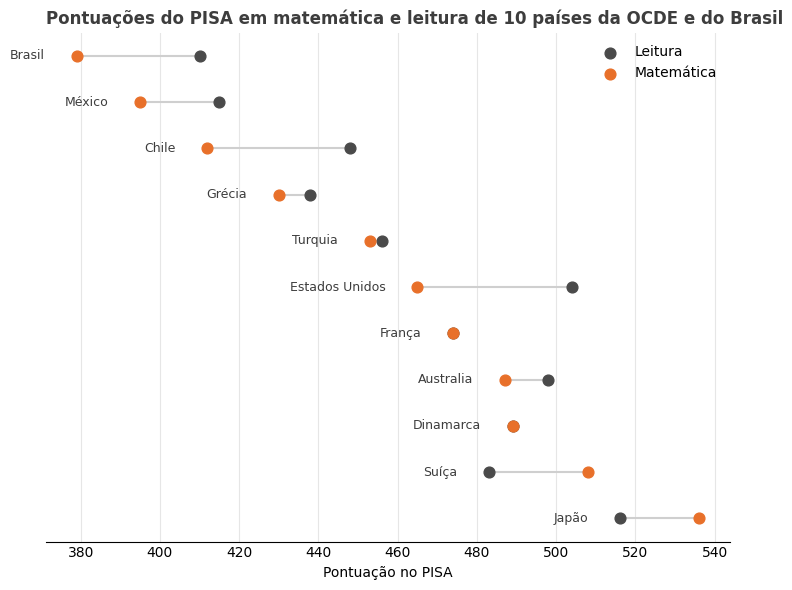

In [5]:
# Mesma versão anterior, mas ordenando os países em ordem decrescente de Matemática
pisa_ordenado = pisa.sort_values("Matemática", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.5, 6))

for pais, matematica, leitura in zip(pisa_ordenado["País"], pisa_ordenado["Matemática"], pisa_ordenado["Leitura"]):
    ax.plot([leitura, matematica], [pais, pais], color="#CFCFCF", zorder=2, linewidth=1.5)
    ponto_esquerdo = min(leitura, matematica)
    ax.text(ponto_esquerdo - 8, pais, pais, ha="right", va="center", fontsize=9, color=GRAFITE)

ax.scatter(pisa_ordenado["Leitura"], pisa_ordenado["País"], color=CORES["Leitura"], zorder=3, label="Leitura", s=60)
ax.scatter(pisa_ordenado["Matemática"], pisa_ordenado["País"], color=CORES["Matemática"], zorder=3, label="Matemática", s=60)

ax.set_xlabel("Pontuação no PISA")
ax.set_title("Pontuações do PISA em matemática e leitura de 10 países da OCDE e do Brasil",
             loc="left", fontsize=12, color=GRAFITE, weight="bold")
ax.xaxis.grid(True, color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.tick_params(length=0)
ax.set_yticklabels([])  # os rótulos já aparecem junto ao ponto mais à esquerda
ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
plt.show()

Uma abordagem consiste em dividir o gráfico em dois grupos: um para países onde as notas de matemática são superiores às de leitura e outro para aqueles onde ocorreu o inverso. Nessas versões (página 100), os grupos são separados e ordenados, utilizando-se títulos maiores e em negrito para distingui-los. Também podemos adicionar valores numéricos — às vezes, eu os posiciono diretamente dentro do círculo —, mas é preciso ter cuidado, pois os rótulos podem poluir o gráfico. Uma alternativa é incluir linhas de grade verticais, dependendo do nível de precisão com que desejamos transmitir os dados ao leitor.

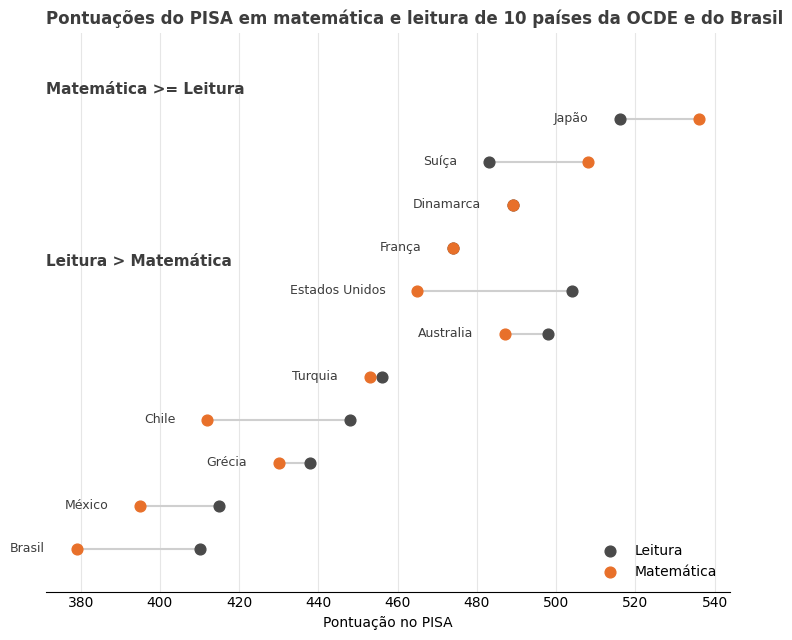

In [6]:
# Dividir os países em dois grupos: Matemática >= Leitura (topo) e Leitura > Matemática (base)
# Cada subgrupo é ordenado em ordem crescente da maior das duas notas
matematica_maior = pisa[pisa["Matemática"] >= pisa["Leitura"]].sort_values("Matemática", ascending=True)
leitura_maior = pisa[pisa["Leitura"] > pisa["Matemática"]].sort_values("Leitura", ascending=True)

# Matemática > Leitura fica no topo, então entra por último na lista (posições mais altas)
ordem = pd.concat([leitura_maior, matematica_maior]).reset_index(drop=True)
pos = np.arange(len(ordem))

fig, ax = plt.subplots(figsize=(7.5, 6.5))

for y, (pais, matematica, leitura) in zip(pos, zip(ordem["País"], ordem["Matemática"], ordem["Leitura"])):
    ax.plot([leitura, matematica], [y, y], color="#CFCFCF", zorder=2, linewidth=1.5)
    ponto_esquerdo = min(leitura, matematica)
    ax.text(ponto_esquerdo - 8, y, pais, ha="right", va="center", fontsize=9, color=GRAFITE)

ax.scatter(ordem["Leitura"], pos, color=CORES["Leitura"], zorder=3, label="Leitura", s=60)
ax.scatter(ordem["Matemática"], pos, color=CORES["Matemática"], zorder=3, label="Matemática", s=60)

# Anotações identificando cada grupo, com destaque em negrito
ax.text(0.0, len(leitura_maior) - 0.5, "Leitura > Matemática", transform=ax.get_yaxis_transform(),
        ha="left", va="bottom", fontsize=11, fontweight="bold", color=GRAFITE)
ax.text(0.0, len(ordem) - 0.5, "Matemática >= Leitura", transform=ax.get_yaxis_transform(),
        ha="left", va="bottom", fontsize=11, fontweight="bold", color=GRAFITE)

# Espaço extra acima do grupo do topo para a anotação não sobrepor o título
ax.set_ylim(-1, len(ordem) + 1)

ax.set_xlabel("Pontuação no PISA")
ax.set_title("Pontuações do PISA em matemática e leitura de 10 países da OCDE e do Brasil",
             loc="left", fontsize=12, color=GRAFITE, weight="bold")
ax.xaxis.grid(True, color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.tick_params(length=0)
ax.set_yticks([])  # os rótulos já aparecem junto ao ponto mais à esquerda
ax.legend(frameon=False, loc="lower right")

fig.tight_layout()
plt.show()

Ao usar um gráfico de pontos para mostrar mudanças ao longo do tempo, prefiro substituir as linhas de conexão por setas, o que ajuda a deixar clara a direção.

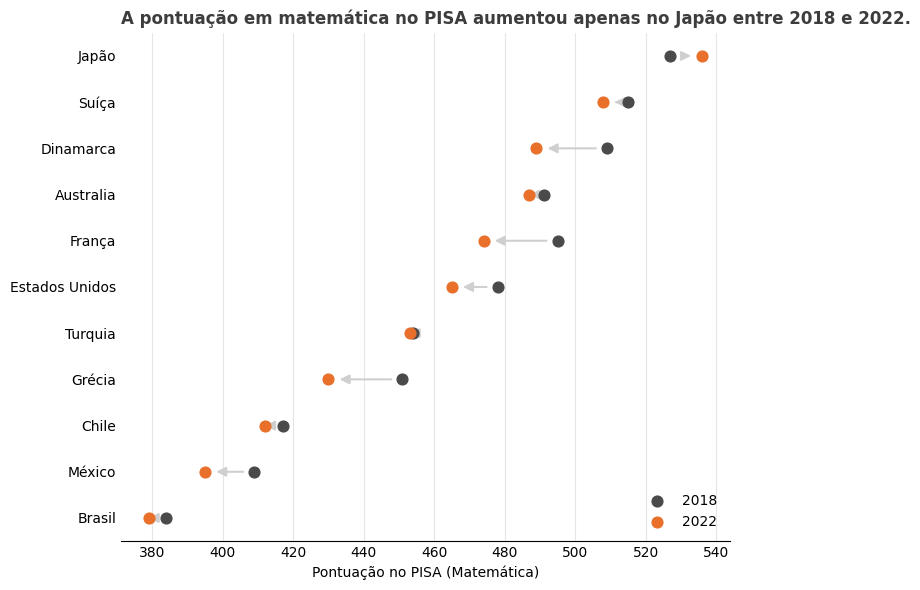

In [7]:
pisa_evolucao = pd.read_csv("../Data/pisa_matematica_evolucao_2018_2022.csv")
pisa_evolucao = pisa_evolucao.sort_values("Matemática_2022", ascending=True).reset_index(drop=True)

CORES_EVOLUCAO = {"Matemática_2018": "#4A4A4A", "Matemática_2022": "#E8702A"}

fig, ax = plt.subplots(figsize=(7.5, 6))

# Seta ligando a nota de 2018 à de 2022, indicando a direção da mudança
for pais, m2018, m2022 in zip(pisa_evolucao["País"], pisa_evolucao["Matemática_2018"], pisa_evolucao["Matemática_2022"]):
    ax.annotate("", xy=(m2022, pais), xytext=(m2018, pais),
                arrowprops=dict(arrowstyle="-|>", color="#CFCFCF", linewidth=1.5,
                                 shrinkA=8, shrinkB=8, mutation_scale=14),
                zorder=2)

ax.scatter(pisa_evolucao["Matemática_2018"], pisa_evolucao["País"],
           color=CORES_EVOLUCAO["Matemática_2018"], zorder=3, label="2018", s=60)
ax.scatter(pisa_evolucao["Matemática_2022"], pisa_evolucao["País"],
           color=CORES_EVOLUCAO["Matemática_2022"], zorder=3, label="2022", s=60)

ax.set_xlabel("Pontuação no PISA (Matemática)")
ax.set_title("A pontuação em matemática no PISA aumentou apenas no Japão entre 2018 e 2022.",
             loc="left", fontsize=12, color=GRAFITE, weight="bold")
ax.xaxis.grid(True, color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.tick_params(length=0)
ax.legend(frameon=False, loc="lower right")

fig.tight_layout()
plt.show()

Vale um alerta adicional sobre gráficos de pontos que mostram mudanças ao longo do tempo. Por definição, o gráfico de pontos é um gráfico de resumo; ele não exibe todos os dados dos anos intermediários. Se os dados entre os dois pontos seguem, de modo geral, a mesma direção, o gráfico de pontos é suficiente. No entanto, se houver variações bruscas de um ano para o outro, o gráfico de pontos ocultará esse padrão (assim como ocorre com os gráficos de barras). Por exemplo, se as notas de testes caíssem entre 2015 e 2019 e, em seguida, subissem drasticamente entre 2019 e 2020, o gráfico de pontos mostraria apenas um aumento geral, mascarando a mudança ocorrida nos anos intermediários. Em alguns casos, você pode não ter escolha: se estiver utilizando dados do Censo decenal dos EUA, terá, por definição, informações apenas para intervalos de dez anos. É uma limitação inevitável, mas, se você dominar bem o assunto, saberá se exibir apenas esses pontos é suficiente para transmitir sua mensagem de forma clara e precisa.